<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Luciano Ceballos - a2110
## Modelo de lenguaje con tokenización por caracteres


### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [54]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

## Descarga del dataset
# descargar de textos.info
import urllib.request
# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

### Datos
Utilizo como dataset la otra de Julio Verne llamada **La vuelta al mundo en 80 dias**.

In [55]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [56]:
# seleccionamos el tamaño de contexto
max_context_size = 100
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

# la longitud de vocabulario de caracteres es:
print(len(chars_vocab))

# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

67


###  Tokenizar

In [57]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]
print(tokenized_text[:10])

[59, 23, 41, 59, 23, 0, 59, 13, 66, 38]


### Organizando y estructurando el dataset

In [58]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

vocab_size = len(chars_vocab)

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

## Funcion callback

In [59]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True

# Modelo 1

In [60]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential
from tensorflow.keras.optimizers import RMSprop

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.
Luego se indican 3 capas mas entrenables, un total de 147.267 parametros entrenables.

In [61]:
model = Sequential()
# Codificación one-hot por carácter
model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
                          input_shape=(None, 1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
# Capa de salida
model.add(Dense(vocab_size, activation="softmax"))
# Compilación con clipnorm para estabilidad
optimizer = RMSprop(learning_rate=0.001, clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, None, 200)      │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,267 (575.26 KB)

 Trainable params: 147,267 (575.26 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

Epoch 1/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.3197
 mean perplexity: 5.36677997366426 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - loss: 2.3196
Epoch 2/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.8096
 mean perplexity: 4.873644086310101 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - loss: 1.8096
Epoch 3/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.7332
 mean perplexity: 4.632952869846131 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - loss: 1.7332
Epoch 4/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6972
 mean perplexity: 4.57002764970518 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - loss: 1.6972
Epoch 5/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.6762
 mean perplexity: 4.447056493178237 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - loss: 1.6762
Epoch 6/20
1389/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.6603
 mean p

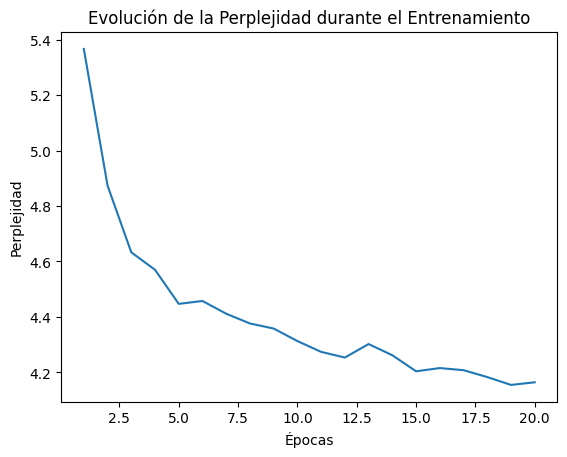

In [62]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
# Etiquetas de los ejes
plt.xlabel("Épocas")
plt.ylabel("Perplejidad")
plt.title("Evolución de la Perplejidad durante el Entrenamiento")
plt.show()

Agregando 1 capa extra al modelo visto en clases y modificando el optimizador a RMSprop se pudo reducir el valor de la perplejidad a 4.15 (el ejemplo visto en clases era de 4.55)

Guardar modelo:

In [ ]:
"""
KERAS_PATH = os.path.join(BASE_DIR, 'model.keras')   # formato nativo recomendado
H5_PATH    = os.path.join(BASE_DIR, 'model.h5')

# guardar el modelo en ambos formatos
model.save(KERAS_PATH)
model.save(H5_PATH)
print(f"Modelo guardado en formato .keras: {KERAS_PATH}")
print(f"Modelo guardado en formato .h5:    {H5_PATH}")
"""

'\nKERAS_PATH = os.path.join(BASE_DIR, \'model.keras\')   # formato nativo recomendado\nH5_PATH    = os.path.join(BASE_DIR, \'model.h5\')\n\n# guardar el modelo en ambos formatos\nmodel.save(KERAS_PATH)\nmodel.save(H5_PATH)\nprint(f"Modelo guardado en formato .keras: {KERAS_PATH}")\nprint(f"Modelo guardado en formato .h5:    {H5_PATH}")\n'

# Modelo 2

Manteniendo la celda SimpleRNN pero haciendola profunda. Además, modifico el One-Hot por una capa de Embedding, que es entrenable y densa.


In [63]:
from keras.layers import Input, SimpleRNN, Dense, Embedding
from keras.models import Sequential

# Defino una dimension para el vector de embedding
embedding_dim = 64 # 64 dimensiones por caracter
model_rnn = Sequential()
# 1 capa de embedding reemplaza la categoryencoding.
model_rnn .add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(None,)))
# 2 primera capa RNN-elman
model_rnn .add(SimpleRNN(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
# 3 segunda capa RNN-elman
model_rnn .add(SimpleRNN(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
# 4 salida
model_rnn.add(Dense(vocab_size, activation='softmax'))
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, None, 64)       │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, None, 256)      │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, None, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, None, 67)       │        17,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,011 (918.01 KB)

 Trainable params: 235,011 (918.01 KB)

 Non-trainable params: 0 (0.00 B)

Este nuevo modelo tiene 235.011 parametros entrenambles, casi 100.000 que la red propuesta inicialmente en esta notebook.

## Entrenamiento

Epoch 1/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 2.3490
 mean perplexity: 5.186627275447555 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 111s 72ms/step - loss: 2.3487
Epoch 2/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.6683
 mean perplexity: 4.70594653199772 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - loss: 1.6683
Epoch 3/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1.5787
 mean perplexity: 4.554521227851132 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - loss: 1.5787
Epoch 4/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.5408
 mean perplexity: 4.4741891810131555 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - loss: 1.5408
Epoch 5/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.5201
 mean perplexity: 4.4171086997550155 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 91s 66ms/step - loss: 1.5201
Epoch 6/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.5062
 me

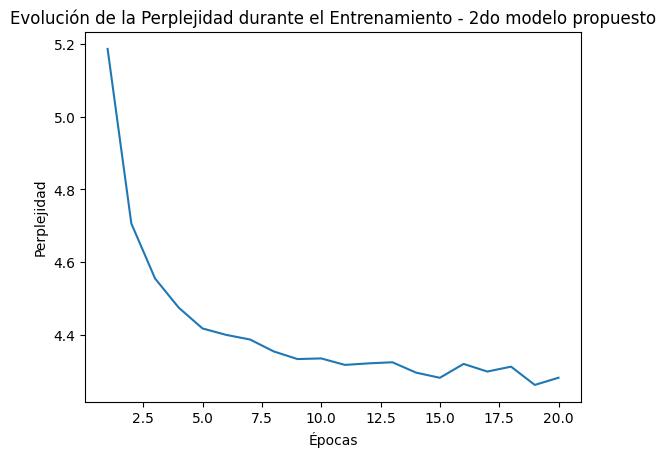

In [64]:
history_ppl = []
hist = model_rnn .fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
# Etiquetas de los ejes
plt.xlabel("Épocas")
plt.ylabel("Perplejidad")
plt.title("Evolución de la Perplejidad durante el Entrenamiento - 2do modelo propuesto")
plt.show()

In [ ]:
"""
KERAS_PATH = os.path.join(BASE_DIR, 'model_rnn.keras')   # formato nativo recomendado
H5_PATH    = os.path.join(BASE_DIR, 'model_rnn.h5')      # legacy HDF5

# guardar el modelo en ambos formatos
model_rnn.save(KERAS_PATH)
model_rnn.save(H5_PATH)
print(f"Modelo guardado en formato .keras: {KERAS_PATH}")
print(f"Modelo guardado en formato .h5:    {H5_PATH}")
"""

'\nKERAS_PATH = os.path.join(BASE_DIR, \'model_rnn.keras\')   # formato nativo recomendado\nH5_PATH    = os.path.join(BASE_DIR, \'model_rnn.h5\')      # legacy HDF5\n\n# guardar el modelo en ambos formatos\nmodel_rnn.save(KERAS_PATH)\nmodel_rnn.save(H5_PATH)\nprint(f"Modelo guardado en formato .keras: {KERAS_PATH}")\nprint(f"Modelo guardado en formato .h5:    {H5_PATH}")\n'

# Modelo 3

Utilizando celdas tipo LSTM.

In [ ]:
from keras.layers import LSTM, Bidirectional
import tensorflow as tf

In [ ]:
model_lstm = Sequential(name='LSTM_Profunda')

# capa encoding embedding
model_lstm .add(Embedding(input_dim = vocab_size, output_dim = embedding_dim, input_shape=(None,)))

# primera capa LSTM bidireccional
model_lstm.add(Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    )
))

# segunda capa LSTM con mas unidades
model_lstm.add(LSTM(
    128,
    return_sequences=True,
    dropout=0.3,
    recurrent_dropout=0.2
))

# tercera capa LSTM
model_lstm.add(LSTM(
    64,
    return_sequences=True,
    dropout=0.3,
    recurrent_dropout=0.2
))


model_lstm.add(TimeDistributed(Dense(128, activation='relu')))
model_lstm.add(TimeDistributed(Dropout(0.2)))

# Capa de salida
model_lstm.add(Dense(vocab_size, activation='softmax'))

# Compilación
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_Profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, None, 64)       │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 128)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 128)      │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, None, 64)       │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 128)      │         8,320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 128)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, None, 67)       │         8,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,291 (1.02 MB)

 Trainable params: 268,291 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

Epoch 1/2
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1616 - loss: 3.0548
 mean perplexity: 169.46479433321105 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2402s 2s/step - accuracy: 0.1617 - loss: 3.0547
Epoch 2/2
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5758 - loss: 1.3132
 mean perplexity: 33.30016467292902 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 2389s 2s/step - accuracy: 0.5758 - loss: 1.3130


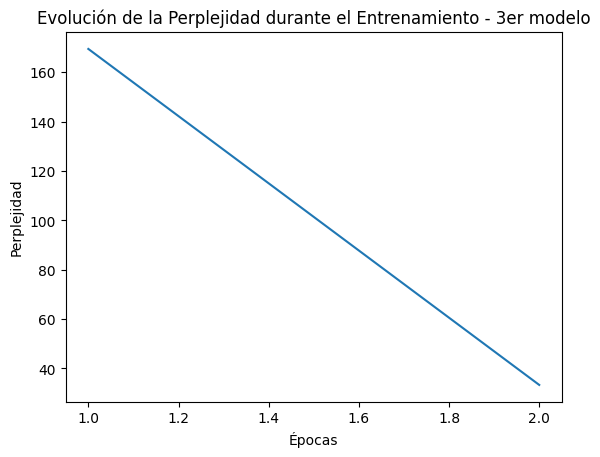

In [ ]:
history_ppl = []
hist = model_lstm .fit(X, y, epochs=2, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
# Etiquetas de los ejes
plt.xlabel("Épocas")
plt.ylabel("Perplejidad")
plt.title("Evolución de la Perplejidad durante el Entrenamiento - 3er modelo")
plt.show()

Por una cuestion de recursos, solo entreno este modelo con 2 epocas, aunque es notable el mal desempeño de esta arquitectura.

### Generación de secuencias

In [65]:
def generate_seq(model, seed_text, max_length, n_char):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): caracteres de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_char (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_char" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_char):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

Utilizando el modelo 1:

In [66]:
input_text = 'habia una vez'
# genero un bucle para mostrar como se generan los caracteres en base a distintas cantidad de caracteres como parametro
for n in range(10, 61, 10):
    print(f"\nGenerando secuencia con n_char = {n}")
    output = generate_seq(model, input_text, max_length=max_context_size, n_char=n)
    print(output)


Generando secuencia con n_char = 10
habia una vez en el cap

Generando secuencia con n_char = 20
habia una vez en el capitán de la

Generando secuencia con n_char = 30
habia una vez en el capitán de la campañía 

Generando secuencia con n_char = 40
habia una vez en el capitán de la campañía de la comp

Generando secuencia con n_char = 50
habia una vez en el capitán de la campañía de la compañía de la

Generando secuencia con n_char = 60
habia una vez en el capitán de la campañía de la compañía de la compañía 


Pruebo lo mismo con un max_context_size = 150, no es recomendable pero sirve para verificar la calidad de las predicciones:

In [67]:
input_text = 'habia una vez'
# genero un bucle para mostrar como se generan los caracteres en base a distintas cantidad de caracteres como parametro
for n in range(10, 61, 10):
    print(f"\nGenerando secuencia con n_char = {n}")
    output = generate_seq(model, input_text, max_length= 150, n_char=n)
    print(output)


Generando secuencia con n_char = 10
habia una vez en el cap

Generando secuencia con n_char = 20
habia una vez en el capitán de la

Generando secuencia con n_char = 30
habia una vez en el capitán de la campañía 

Generando secuencia con n_char = 40
habia una vez en el capitán de la campañía de la comp

Generando secuencia con n_char = 50
habia una vez en el capitán de la campañía de la compañía de la

Generando secuencia con n_char = 60
habia una vez en el capitán de la campañía de la compañía de la compañía 


Ahora con max_content_size = 50

In [68]:
input_text = 'habia una vez'
# genero un bucle para mostrar como se generan los caracteres en base a distintas cantidad de caracteres como parametro
for n in range(10, 61, 10):
    print(f"\nGenerando secuencia con n_char = {n}")
    output = generate_seq(model, input_text, max_length= 50, n_char=n)
    print(output)


Generando secuencia con n_char = 10
habia una vez en el cap

Generando secuencia con n_char = 20
habia una vez en el capitán de la

Generando secuencia con n_char = 30
habia una vez en el capitán de la campañía 

Generando secuencia con n_char = 40
habia una vez en el capitán de la campañía de la comp

Generando secuencia con n_char = 50
habia una vez en el capitán de la campañía de la compañía de la

Generando secuencia con n_char = 60
habia una vez en el capitán de la campañía de la compañía de la compañía 


Utilizando el modelo 2:

In [69]:
input_text = 'habia una vez'
# genero un bucle para mostrar como se generan los caracteres en base a distintas cantidad de caracteres como parametro
for n in range(10, 61, 10):
    print(f"\nGenerando secuencia con n_char = {n}")
    output = generate_seq(model_rnn, input_text, max_length=max_context_size, n_char=n)
    print(output)


Generando secuencia con n_char = 10
habia una vez en el cam

Generando secuencia con n_char = 20
habia una vez en el camino de la 

Generando secuencia con n_char = 30
habia una vez en el camino de la compañía d

Generando secuencia con n_char = 40
habia una vez en el camino de la compañía de la compa

Generando secuencia con n_char = 50
habia una vez en el camino de la compañía de la compañía de la 

Generando secuencia con n_char = 60
habia una vez en el camino de la compañía de la compañía de la compañía d


Genera lo mismo con un max_content_size=150

In [70]:
input_text = 'habia una vez'
# genero un bucle para mostrar como se generan los caracteres en base a distintas cantidad de caracteres como parametro
for n in range(10, 61, 10):
    print(f"\nGenerando secuencia con n_char = {n}")
    output = generate_seq(model_rnn, input_text, max_length= 150, n_char=n)
    print(output)


Generando secuencia con n_char = 10
habia una vez en el cam

Generando secuencia con n_char = 20
habia una vez en el camino de la 

Generando secuencia con n_char = 30
habia una vez en el camino de la compañía d

Generando secuencia con n_char = 40
habia una vez en el camino de la compañía de la compa

Generando secuencia con n_char = 50
habia una vez en el camino de la compañía de la compañía de la 

Generando secuencia con n_char = 60
habia una vez en el camino de la compañía de la compañía de la compañía d


Ahora con max_content_size=50

In [71]:
input_text = 'habia una vez'
# genero un bucle para mostrar como se generan los caracteres en base a distintas cantidad de caracteres como parametro
for n in range(10, 61, 10):
    print(f"\nGenerando secuencia con n_char = {n}")
    output = generate_seq(model_rnn, input_text, max_length= 50, n_char=n)
    print(output)


Generando secuencia con n_char = 10
habia una vez en el cam

Generando secuencia con n_char = 20
habia una vez en el camino de la 

Generando secuencia con n_char = 30
habia una vez en el camino de la compañía d

Generando secuencia con n_char = 40
habia una vez en el camino de la compañía de la compa

Generando secuencia con n_char = 50
habia una vez en el camino de la compañía de la compañía de la 

Generando secuencia con n_char = 60
habia una vez en el camino de la compañía de la compañía de la compañía d


Generacion de secuencias pero con temperatura variable:

In [72]:
def generate_seq(model, seed_text, max_length, n_char, temperature=1.0,
                 char2idx=None, idx2char=None, pad_id=0, padding_mode='pre'):
    """
    Genera texto carácter a carácter usando muestreo con temperatura.

    Args:
        model (keras.Model): modelo entrenado que devuelve (batch, T, vocab) con softmax.
        seed_text (str): texto de entrada inicial.
        max_length (int): longitud máxima del contexto.
        n_char (int): cantidad de caracteres a generar.
        temperature (float): >0.0; 1.0 = sin cambio; <1.0 = más conservador; >1.0 = más aleatorio.
        char2idx (dict): mapa char->id.
        idx2char (dict): mapa id->char.
        pad_id (int): id del token de padding
        padding_mode (str): 'pre' (left-padding) o 'post' (right-padding). Debe coincidir con entrenamiento.

    Returns:
        str: texto generado.
    """
    assert char2idx is not None and idx2char is not None, "char2idx/idx2char son requeridos."

    output_text = seed_text
    # codifico seed
    encoded = [char2idx[ch] for ch in output_text.lower() if ch in char2idx]

    for _ in range(n_char):
        # Pad/truncate para mantener longitud de contexto
        x = pad_sequences([encoded], maxlen=max_length, padding=padding_mode, truncating=padding_mode, value=pad_id)

        # prediccion: (1, T, vocab); tomamos ultimo timestep
        preds = model.predict(x, verbose=0)
        probs = preds[0, -1, :]  # vector de tamaño vocab con probabilidades

        # ajuste por temperatura
        if temperature is None or temperature <= 0:
            # caso limite: greedy
            next_id = int(np.argmax(probs))
        else:
            # convertir a log-prob, reescalar por temperatura, volver a probs
            log_p = np.log(probs + 1e-12)
            log_p = log_p / temperature
            p = np.exp(log_p)
            p = p / p.sum()
            # muestreo categórico
            next_id = int(np.random.choice(len(p), p=p))

        # Decodificar carácter
        next_char = idx2char.get(next_id, '')
        output_text += next_char

        # Actualizar contexto (append del id generado)
        encoded.append(next_id)
        # Mantener ventana de contexto
        if len(encoded) > max_length:
            encoded = encoded[-max_length:] if padding_mode == 'post' else encoded[-max_length:]

    return output_text

Genero secuencias con esta nueva forma de generar secuencias:

In [73]:
input_text = 'habia una vez'
for temp in [0.7, 1.0, 1.3]:
    print(f"\nTemperatura = {temp}")
    out = generate_seq(model, input_text, max_length=max_context_size, n_char=30,
                       temperature=temp, char2idx=char2idx, idx2char=idx2char,
                       pad_id=0, padding_mode='pre')
    print(out)



Temperatura = 0.7
habia una vez en las velas el general debía

Temperatura = 1.0
habia una vez con brazo de no que la "tuas,

Temperatura = 1.3
habia una vez en bolocado con las ispenes d


Utilizando el modelo model_rnn

In [74]:
input_text = 'habia una vez'
# Probá varios valores para ver el efecto
for temp in [0.7, 1.0, 1.3]:
    print(f"\nTemperatura = {temp}")
    out = generate_seq(model_rnn, input_text, max_length=max_context_size, n_char=30,
                       temperature=temp, char2idx=char2idx, idx2char=idx2char,
                       pad_id=0, padding_mode='pre')
    print(out)


Temperatura = 0.7
habia una vez de la 
mar, habían las 
elefa

Temperatura = 1.0
habia una vez el maquiniste con que había o

Temperatura = 1.3
habia una vez os quetecimiento mil luz. una


###  Beam search y muestreo aleatorio

In [75]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [76]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

Prediccion en modo deterministico:

In [81]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")
#print('Salidas generadas',salidas)
# para ver las salidas
print(decode(salidas[0]))

habia una vez de la mañana, pero 


Prediccion en modo estocastico:

Baja temperatura:

In [82]:
salidas = beam_search(
    model,
    num_beams=10,
    num_words=20,
    input="habia una vez",
    mode='sto',
    temp=0.7
)

In [83]:
#print('Salidas generadas',salidas)
# para ver las salidas
print(decode(salidas[0]))

habia una vez de las ciudad de la


Temperatura mas elevada (mas aleatorio):

In [84]:
salidas = beam_search(
    model,
    num_beams=10,
    num_words=20,
    input="habia una vez",
    mode='sto',
    temp=1.5
)

In [85]:
# para ver las salidas
print(decode(salidas[0]))

habia una vez que este pasajeroso
